# Setup, załadowanie bibliotek i obrazów


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imgA = cv2.imread("A.bmp")
imgB = cv2.imread("B.bmp")
imgC = cv2.imread("C.bmp")
imageBin1 = cv2.imread("binary1.bmp")
imageBin3 = cv2.imread("binary3.bmp")
imgText = cv2.imread("text1.bmp")


# Zadanie 1


## Zadanie 1.a - Binaryzacja obrazu z ustalonym progiem


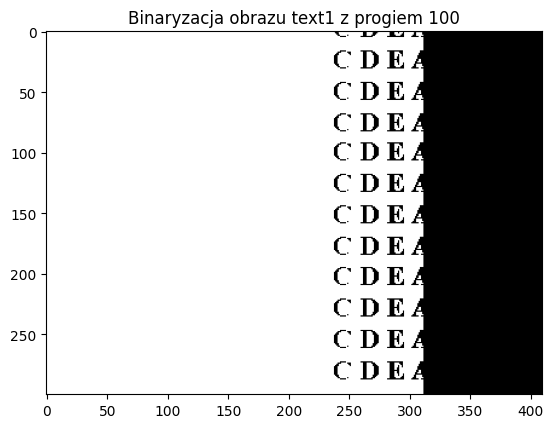

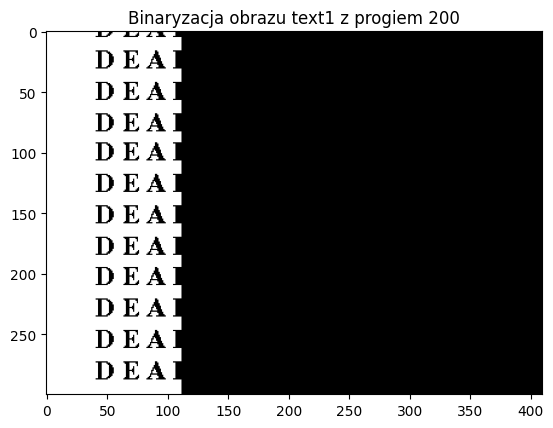

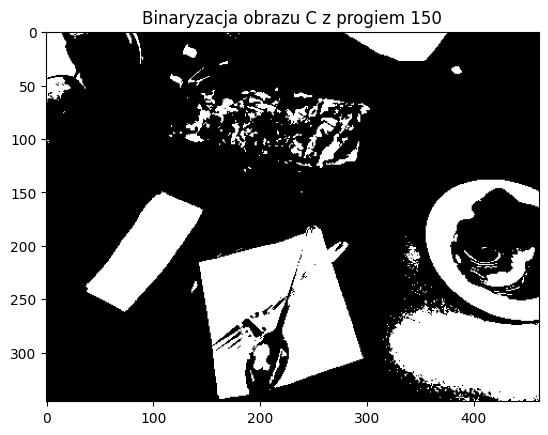

In [ ]:
def binaryzacjaProgiem(img, prog):
    """Funkcja binaryzująca obraz z ustalonym progiem.
    Args:
        img: obraz MONOCHROMATYCZNY do binaryzacji
        prog: próg binaryzacji"""
    x, y, _ = img.shape
    binarizedImg = np.zeros((x, y, 3), dtype=np.uint8)
    plt.show()
    for i in range(x):
        for j in range(y):
            if img[i][j][0] < prog:
                binarizedImg[i][j] = [0, 0, 0]
            else:
                binarizedImg[i][j] = [255, 255, 255]

    return binarizedImg


## Zadanie 1.a - Binaryzacja obrazu z ustalonym progiem

plt.imshow(binaryzacjaProgiem(imgText, 100))
plt.title("Binaryzacja obrazu text1 z progiem 100")
plt.show()

plt.imshow(binaryzacjaProgiem(imgText, 200))
plt.title("Binaryzacja obrazu text1 z progiem 200")
plt.show()

plt.imshow(binaryzacjaProgiem(imgC, 150))
plt.title("Binaryzacja obrazu C z progiem 150")
plt.show()


## Zadanie 1.b - binaryzacja obrazu z progiem wyznaczonym metodą Otsu


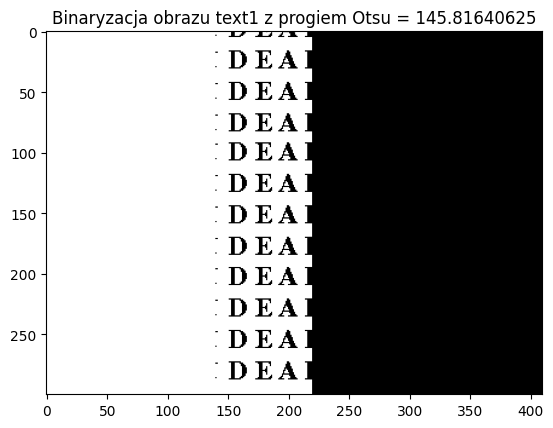

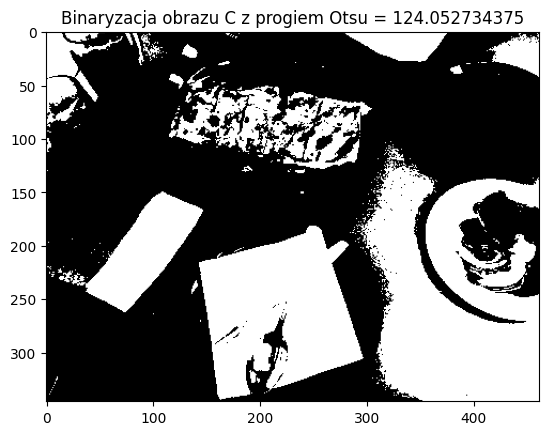

In [ ]:
def otsuThreshold(img):
    # Obrazy wejściowe są 8-bitowe, więc liczba poziomów szarości wynosi 256
    hist, bin_edges = np.histogram(img, bins=256)

    # Calculate centers of bins
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    # Iterate over all thresholds (indices) and get the probabilities w1(t), w2(t)
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]

    # Get the class means mu0(t)
    mean1 = np.cumsum(hist * bin_mids) / weight1
    # Get the class means mu1(t)
    mean2 = (np.cumsum((hist * bin_mids)[::-1]) / weight2[::-1])[::-1]

    inter_class_variance = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2

    # Maximize the inter_class_variance function val
    index_of_max_val = np.argmax(inter_class_variance)

    threshold = bin_mids[:-1][index_of_max_val]
    return threshold


calculatedThresholdA = otsuThreshold(imgText)
binarizedImgText_Otsu = binaryzacjaProgiem(imgText, calculatedThresholdA)

calculatedThresholdC = otsuThreshold(imgC)
binarizedImgC_Otsu = binaryzacjaProgiem(imgC, calculatedThresholdC)
plt.imshow(binarizedImgText_Otsu)
plt.title("Binaryzacja obrazu text1 z progiem Otsu = " + str(calculatedThresholdA))
plt.show()
plt.imshow(binarizedImgC_Otsu)
plt.title("Binaryzacja obrazu C z progiem Otsu = " + str(calculatedThresholdC))
plt.show()


## Zadanie 1.c - lokalna binaryzacja obrazu jako średnia z otoczenia 21x21 pikseli dla każdego piksela.

Jeśli pixel leży zbyt blisko którejś krawędzi obrazu, rozmiar otoczenia powinien być
odpowiednio mniejszy (pomijamy pixele, które wychodziłyby poza granice obrazu).


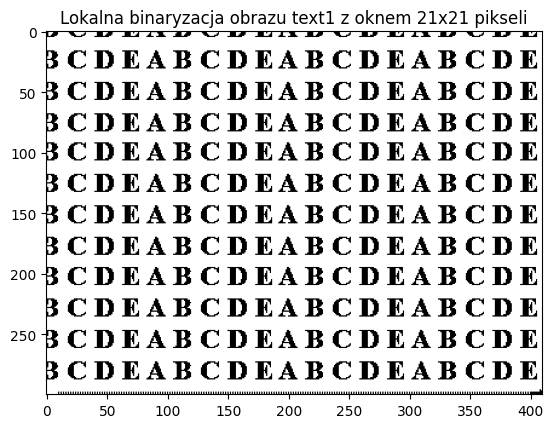

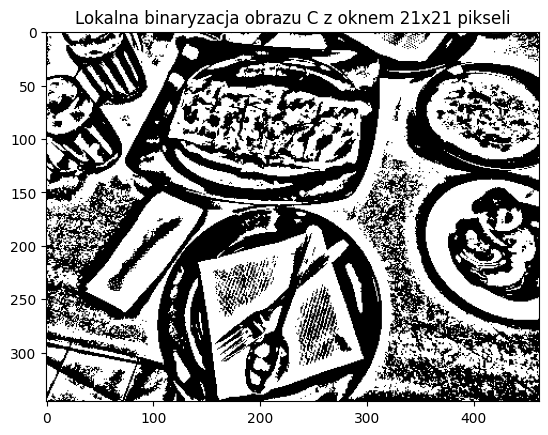

In [ ]:
def localBinaryzation(img, window_size):
    x, y, _ = img.shape
    binarizedImg = np.zeros((x, y, 3), dtype=np.uint8)
    offset = window_size // 2

    for i in range(x):
        for j in range(y):
            x_start = max(0, i - offset)
            x_end = min(x, i + offset + 1)
            y_start = max(0, j - offset)
            y_end = min(y, j + offset + 1)

            neighborhood = img[x_start:x_end, y_start:y_end]

            average = np.average(neighborhood)

            if img[i][j][0] < average:
                binarizedImg[i][j] = [0, 0, 0]
            else:
                binarizedImg[i][j] = [255, 255, 255]

    return binarizedImg


binarizedImgText_Local = localBinaryzation(imgText, 21)
binarizedImgC_Local = localBinaryzation(imgC, 21)
plt.imshow(binarizedImgText_Local)
plt.title("Lokalna binaryzacja obrazu text1 z oknem 21x21 pikseli")
plt.show()

plt.imshow(binarizedImgC_Local)
plt.title("Lokalna binaryzacja obrazu C z oknem 21x21 pikseli")
plt.show()

# Zadanie 2 - usrednianie obrazu na podstawie prostokatnego otoczenia


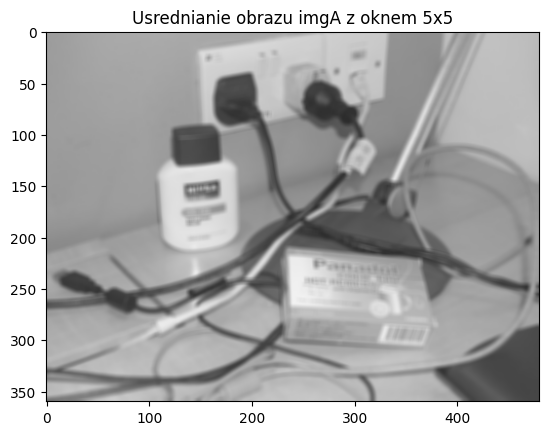

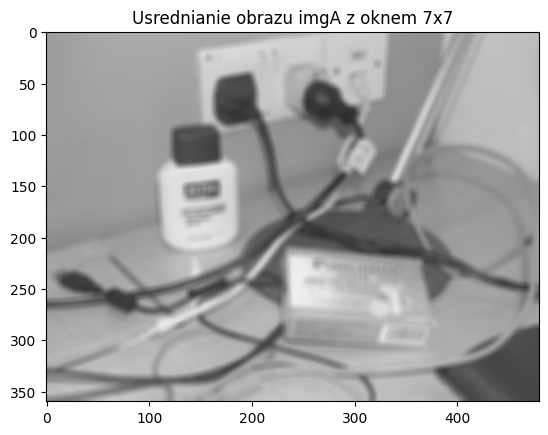

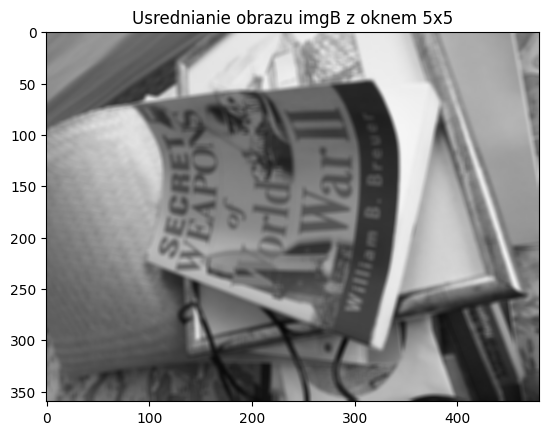

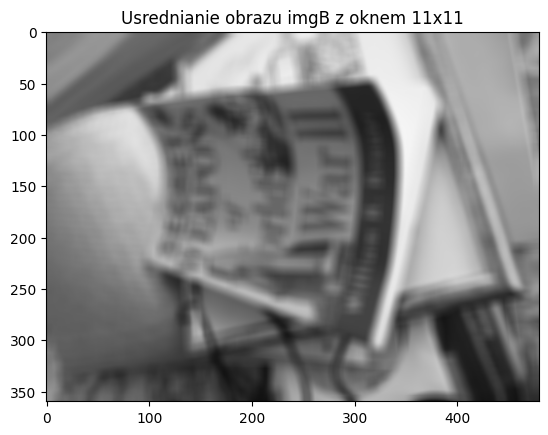

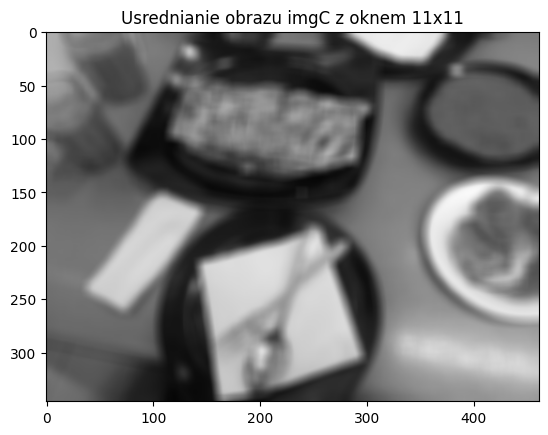

In [ ]:
def usrednianieObrazu(img, windowX, windowY):
    x, y, _ = img.shape
    averagedImg = np.zeros((x, y, 3), dtype=np.uint8)
    offsetX = windowX // 2
    offsetY = windowY // 2

    for i in range(x):
        for j in range(y):
            x_start = max(0, i - offsetX)
            x_end = min(x, i + offsetX + 1)
            y_start = max(0, j - offsetY)
            y_end = min(y, j + offsetY + 1)

            neighborhood = img[x_start:x_end, y_start:y_end]

            average = np.average(neighborhood)

            averagedImg[i][j] = average

    return averagedImg


avgImages = []

avgImages.append((usrednianieObrazu(imgA, 5, 5), "imgA", "5x5"))
avgImages.append((usrednianieObrazu(imgA, 7, 7), "imgA", "7x7"))
avgImages.append((usrednianieObrazu(imgB, 5, 5), "imgB", "5x5"))
avgImages.append((usrednianieObrazu(imgB, 11, 11), "imgB", "11x11"))
avgImages.append((usrednianieObrazu(imgC, 11, 11), "imgC", "11x11"))


for img, name, window in avgImages:
    plt.imshow(img)
    plt.title("Usrednianie obrazu " + name + " z oknem " + window)
    plt.show()

# Zadanie 3 - wyznaczanie krawedzi w obrazach monochromatycznych za pomocą operatora Sobela.

Do realizacji NIE UŻYWAJ gotowych rozwiązań dostępnych w Matlabie, tzn. napisz te funkcje
prawie „od zera”. Dopuszczalne jest jedynie użycie funkcji filter2.


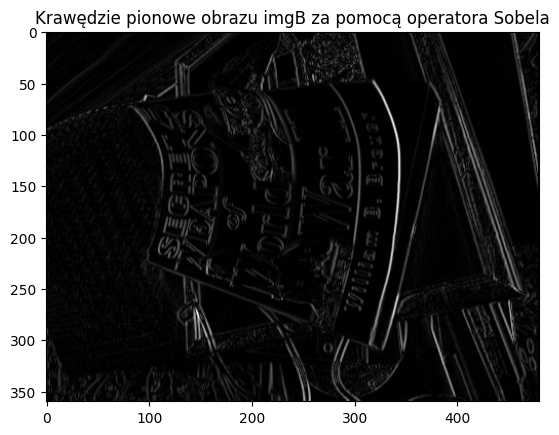

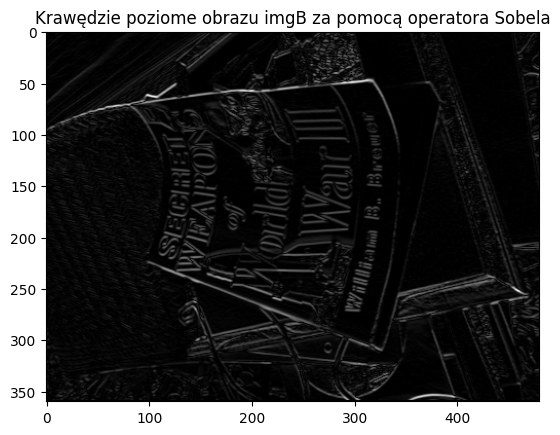

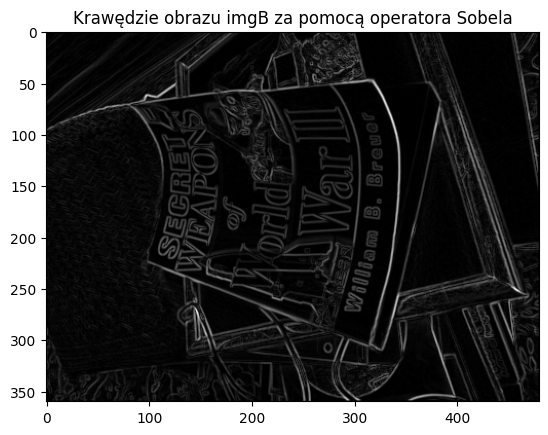

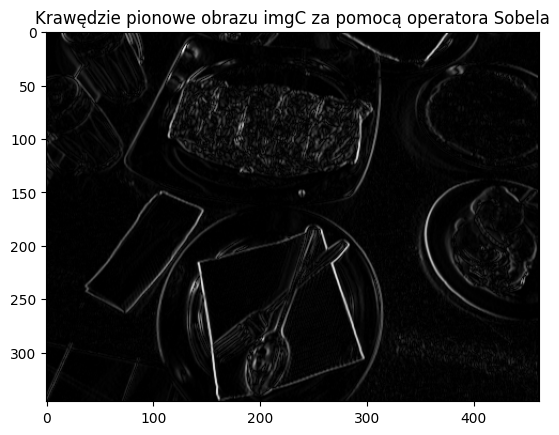

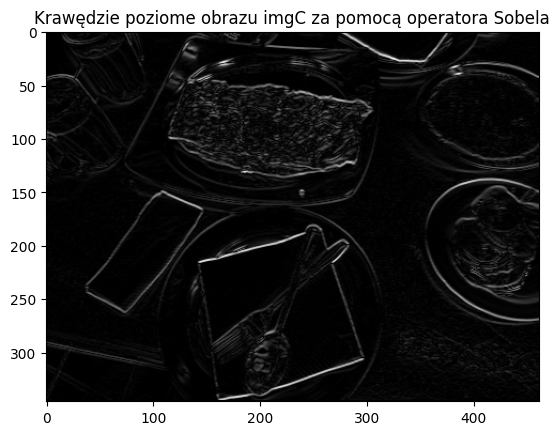

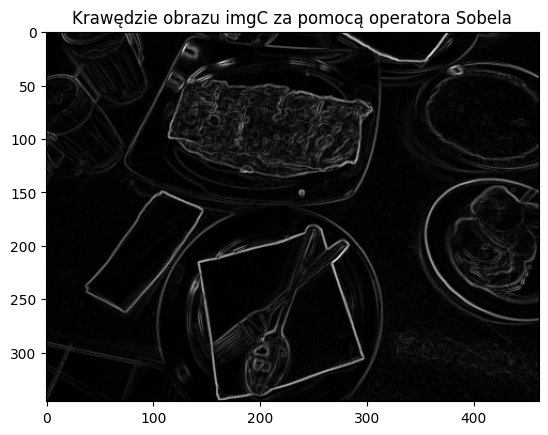

In [ ]:
def zad3(img, N):
    sobel_vertical = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
    sobel_horizontal = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    double_img = np.astype(img, np.float64)
    vertical_edges = abs(cv2.filter2D(double_img, -1, sobel_vertical))
    horizontal_edges = abs(cv2.filter2D(double_img, -1, sobel_horizontal))

    img_edges = vertical_edges + horizontal_edges

    # normalizacja gradientów
    vertical_edges = 255 * vertical_edges / np.max(vertical_edges)
    horizontal_edges = 255 * horizontal_edges / np.max(horizontal_edges)
    img_edges = 255 * img_edges / np.max(img_edges)

    return (
        img_edges.astype(np.uint8),
        vertical_edges.astype(np.uint8),
        horizontal_edges.astype(np.uint8),
    )


images = []
images.append((imgB, "imgB"))
images.append((imgC, "imgC"))

for img, name in images:
    edges, vertical, horizontal = zad3(img, 3)
    plt.imshow(vertical, cmap="gray")
    plt.title("Krawędzie pionowe obrazu " + name + " za pomocą operatora Sobela")
    plt.show()

    plt.imshow(horizontal, cmap="gray")
    plt.title("Krawędzie poziome obrazu " + name + " za pomocą operatora Sobela")
    plt.show()

    plt.imshow(edges, cmap="gray")
    plt.title("Krawędzie obrazu " + name + " za pomocą operatora Sobela")
    plt.show()


# Zadanie 4 - wyznaczanie liczby Eulera w obrazach binarnych. Obrazy czarne, tło białe.

stosujemy zasadę 4-spójności dla czarnych obszarów


In [ ]:
def liczbaEulera(img):
    # liczba eulera - liczba spójnych obiektów - liczba dzuir w nich
    x, y, d = img.shape
    num_obj_pixels = 0
    num_obj_pairs = 0
    num_obj_quads = 0
    for i in range(x):
        for j in range(y):
            if img[i][j][0] == 0:  # czarny piksel
                num_obj_pixels += 1
                if i < x - 1 and img[i + 1][j][0] == 0:  # para pionowa
                    num_obj_pairs += 1
                if j < y - 1 and img[i][j + 1][0] == 0:  # para pozioma
                    num_obj_pairs += 1
                if (
                    i < x - 1
                    and j < y - 1
                    and img[i + 1][j][0] == 0
                    and img[i][j + 1][0] == 0
                    and img[i + 1][j + 1][0] == 0
                ):  # czwórka
                    num_obj_quads += 1
    euler_number = num_obj_pixels - num_obj_pairs + num_obj_quads
    return euler_number


binaryImages = []
binaryImages.append((imageBin1, "binary1"))
binaryImages.append((imageBin3, "binary3"))
for img, name in binaryImages:
    euler_num = liczbaEulera(img)
    print("Liczba Eulera dla obrazu " + name + ": " + str(euler_num))

Liczba Eulera dla obrazu binary1: 1
Liczba Eulera dla obrazu binary3: 1
